In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Importing necessary libraries**

In [ ]:
df = pd.read_csv("/content/calorie_efficiency_dataset.csv")   # change path
df.head()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency


**Loading dataset**

In [ ]:
print("Before:", df.shape)

if len(df) > 10000:
    df = df.sample(n=10000, random_state=42)
else:
    print("Dataset has less than 10,000 rows, using full data")

df.reset_index(drop=True, inplace=True)

print("After:", df.shape)

Before: (39330, 15)
After: (10000, 15)


**Taking sample of dataset because it has 1M records**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       10000 non-null  int64  
 1   steps_per_day             10000 non-null  int64  
 2   active_minutes            10000 non-null  int64  
 3   calories_burned           10000 non-null  int64  
 4   sleep_hours               10000 non-null  float64
 5   hydration_liters          10000 non-null  float64
 6   bmi                       10000 non-null  float64
 7   workouts_per_week         10000 non-null  int64  
 8   muscle_mass_ratio         10000 non-null  float64
 9   body_fat_percentage       10000 non-null  float64
 10  heart_rate_resting        10000 non-null  float64
 11  heart_rate_avg            10000 non-null  float64
 12  continuous_exercise_days  10000 non-null  int64  
 13  efficiency_score          10000 non-null  float64
 14  calorie

**Data Analysis**

In [ ]:
df.isnull().sum()

,0
age,0
steps_per_day,0
active_minutes,0
calories_burned,0
sleep_hours,0
hydration_liters,0
bmi,0
workouts_per_week,0
muscle_mass_ratio,0
body_fat_percentage,0


In [ ]:
df = df.dropna()

In [ ]:
df.describe()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score
count,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000
mean,40.942700,6996.208700,69.692600,1500.0,6.503301,2.497757,24.227303,2.991300,0.349781,0.249170,66.004260,106.011830,2.44290,0.87654
std,13.640837,2445.285386,28.216217,0.0,1.204118,0.787771,5.312389,1.685737,0.077614,0.096674,5.705313,11.301436,1.70676,0.62731
min,18.000000,1000.000000,10.000000,1500.0,3.000000,0.500000,16.000000,0.000000,0.200000,0.050000,50.000000,80.000000,1.00000,0.00300
25%,29.000000,5361.000000,50.000000,1500.0,5.690000,1.960000,20.167500,2.000000,0.295000,0.181750,62.100000,98.400000,1.00000,0.55775
50%,41.000000,7001.500000,70.000000,1500.0,6.500000,2.490000,24.050000,3.000000,0.349000,0.249000,66.000000,106.000000,2.00000,0.72800
75%,53.000000,8631.250000,89.000000,1500.0,7.330000,3.040000,27.930000,4.000000,0.404000,0.316000,69.900000,113.600000,3.00000,0.99000
max,64.000000,16344.000000,176.000000,1500.0,10.000000,5.000000,40.000000,7.000000,0.600000,0.500000,86.200000,148.600000,7.00000,6.65400


In [ ]:
df.nunique()

,0
age,47
steps_per_day,5966
active_minutes,156
calories_burned,1
sleep_hours,662
hydration_liters,427
bmi,2012
workouts_per_week,8
muscle_mass_ratio,375
body_fat_percentage,446


In [ ]:
def assign_diet(row):
    if row['body_fat_percentage'] > 0.30:
        return "Weight Loss Diet"
    elif row['muscle_mass_ratio'] > 0.45:
        return "High Protein Diet"
    elif row['bmi'] > 28:
        return "Low Carb Diet"
    else:
        return "Balanced Diet"

df['nutrition_plan'] = df.apply(assign_diet, axis=1)

df.head()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency,nutrition_plan
0,61,8617,70,1500,6.69,3.58,21.58,1,0.303,0.189,62.0,99.9,5,0.904,Low Efficiency,Balanced Diet
1,34,6570,65,1500,5.79,4.48,24.92,3,0.283,0.050,68.0,110.2,1,0.757,Low Efficiency,Balanced Diet
2,32,9187,109,1500,7.36,3.32,20.28,3,0.434,0.307,58.9,92.5,5,0.937,Low Efficiency,Weight Loss Diet
3,29,12607,106,1500,6.22,2.37,16.00,0,0.505,0.223,57.4,107.3,1,0.351,Low Efficiency,High Protein Diet
4,40,5378,52,1500,4.40,2.92,24.69,1,0.293,0.500,69.3,97.2,2,0.597,Low Efficiency,Weight Loss Diet


**Creating target variable**

In [ ]:
import numpy as np

def add_noise(label):
    if np.random.rand() < 0.15:
        return np.random.choice([
            "Weight Loss Diet",
            "High Protein Diet",
            "Low Carb Diet",
            "Balanced Diet"
        ])
    return label

df['nutrition_plan'] = df['nutrition_plan'].apply(add_noise)

In [ ]:
df['nutrition_plan'].value_counts()

,count
nutrition_plan,
Balanced Diet,4400
Weight Loss Diet,2930
Low Carb Diet,1682
High Protein Diet,988


**Splitting the data **

In [ ]:
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df,
    train_size=0.8,
    stratify=df['nutrition_plan'],
    random_state=42
)

df = df_sample.reset_index(drop=True)

print(df.shape)
print(df['nutrition_plan'].value_counts())

(8000, 16)
nutrition_plan
Balanced Diet        3520
Weight Loss Diet     2344
Low Carb Diet        1346
High Protein Diet     790
Name: count, dtype: int64


**Data visulization**

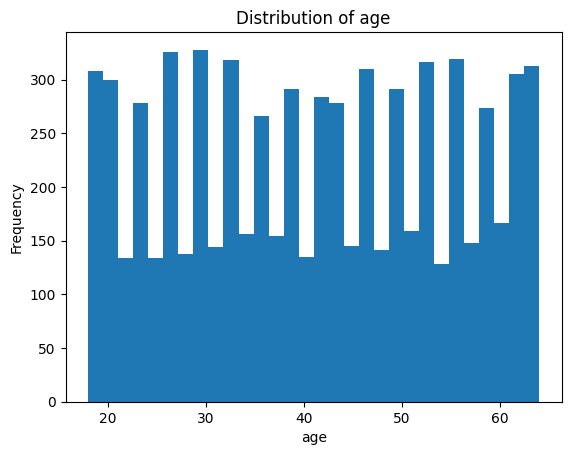

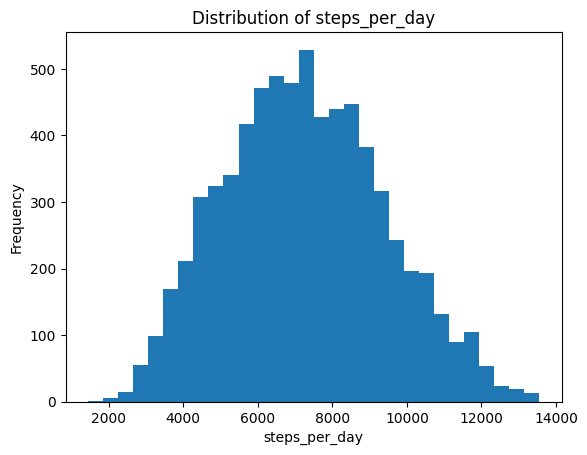

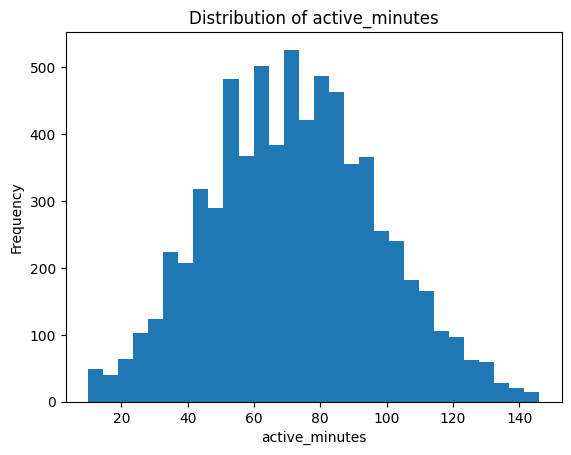

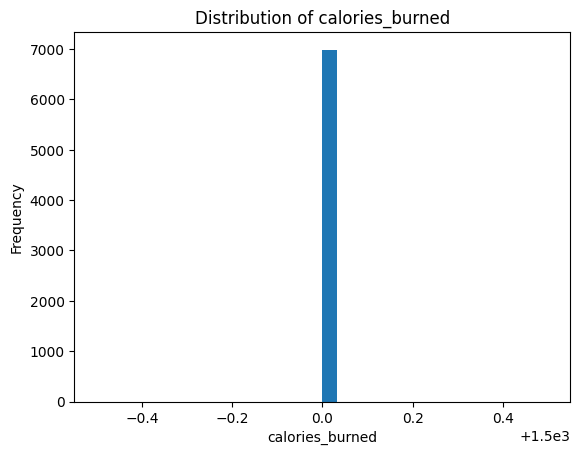

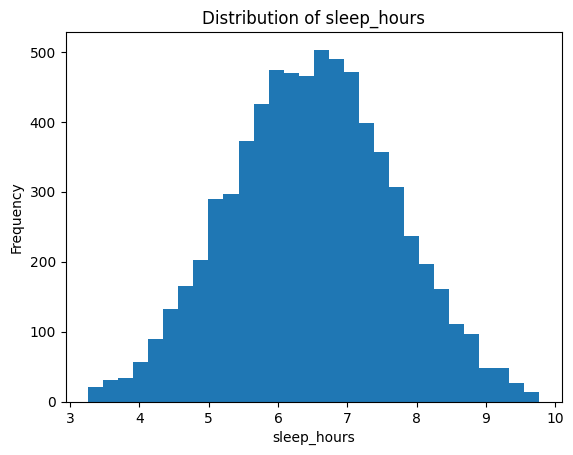

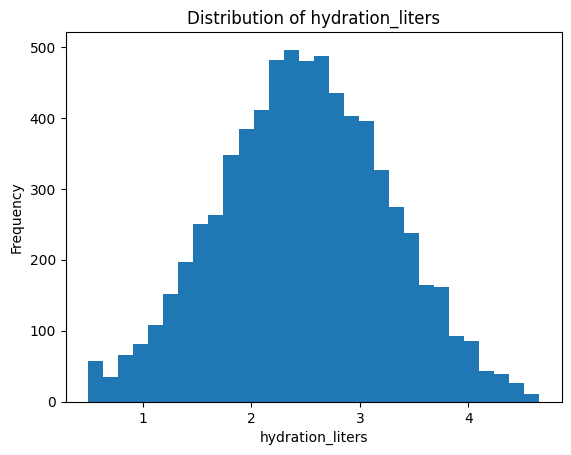

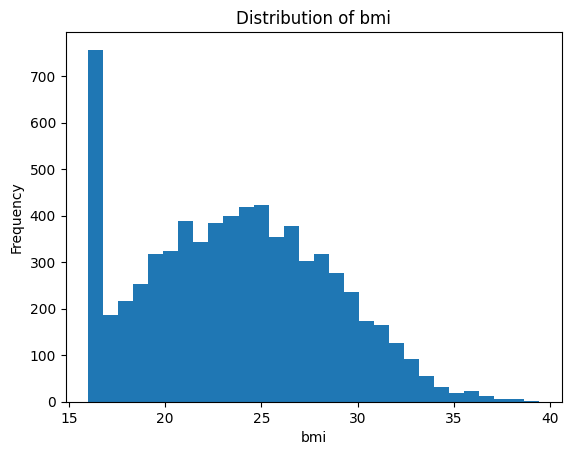

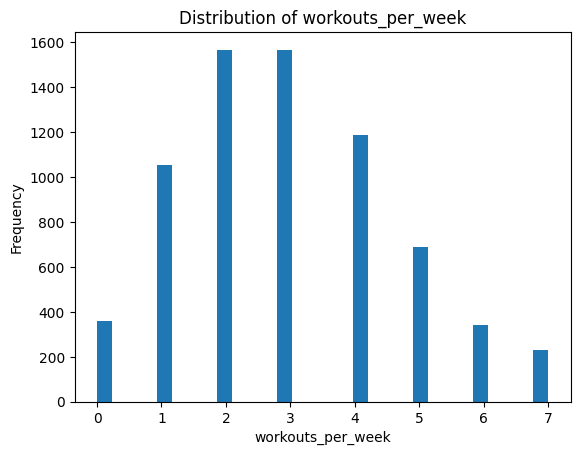

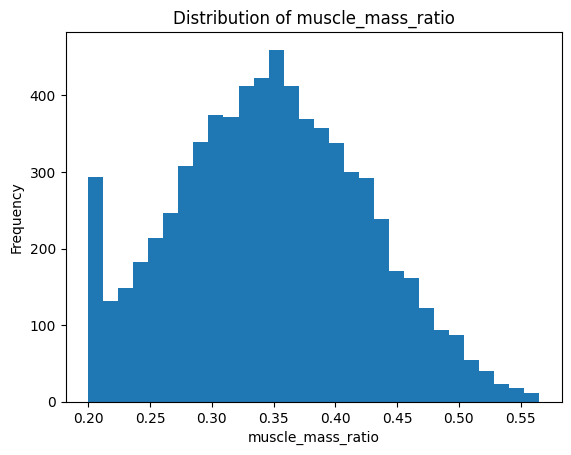

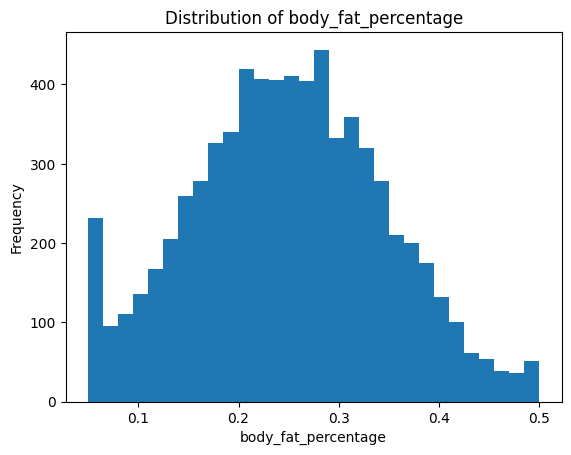

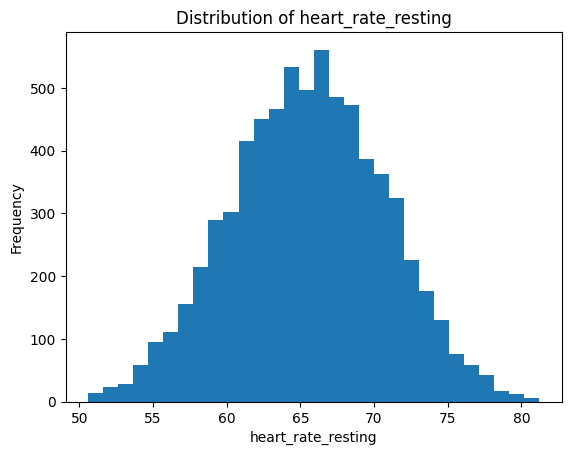

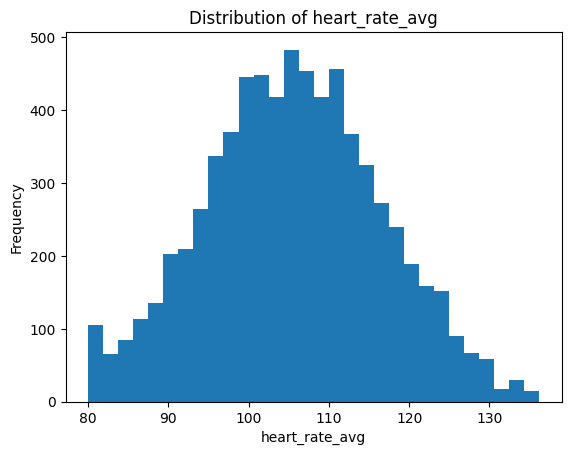

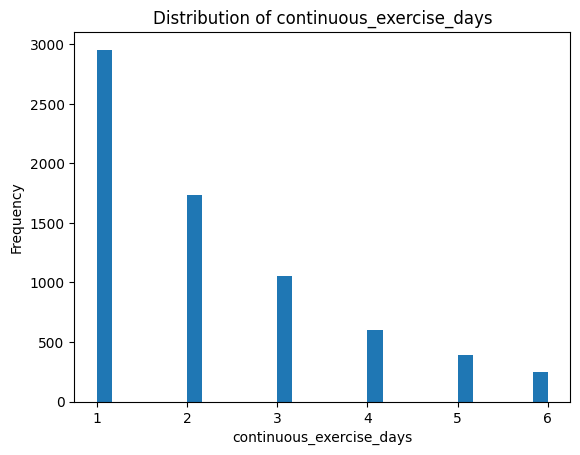

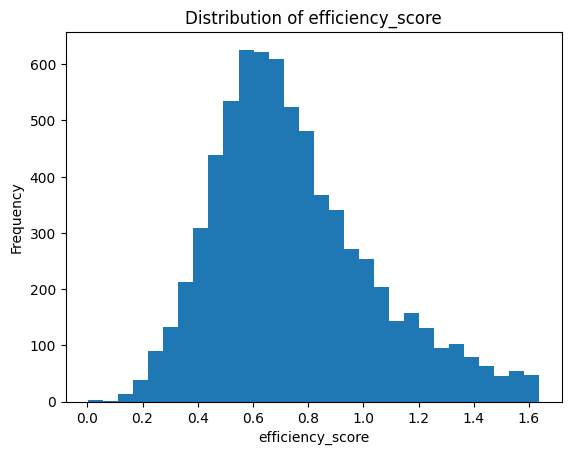

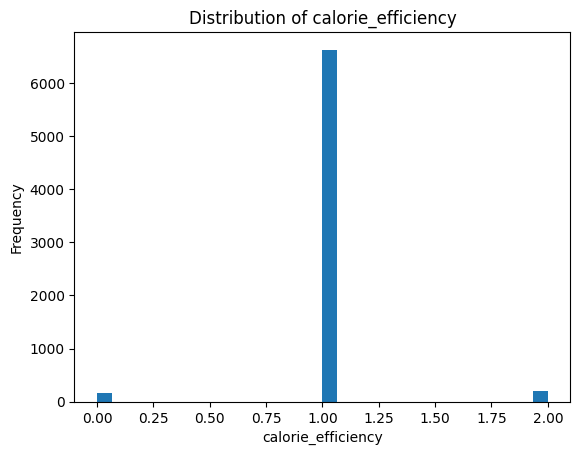

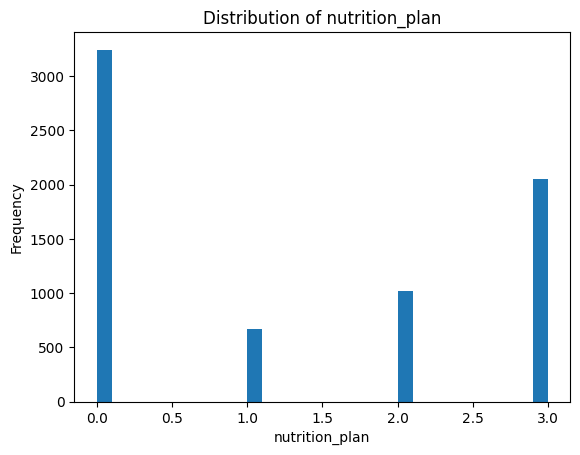

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

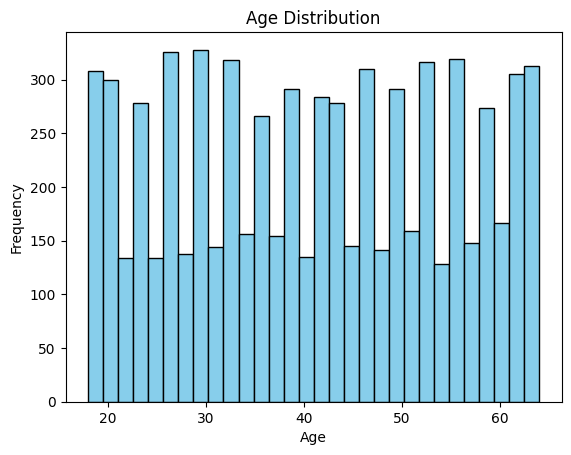

In [ ]:
plt.figure()
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

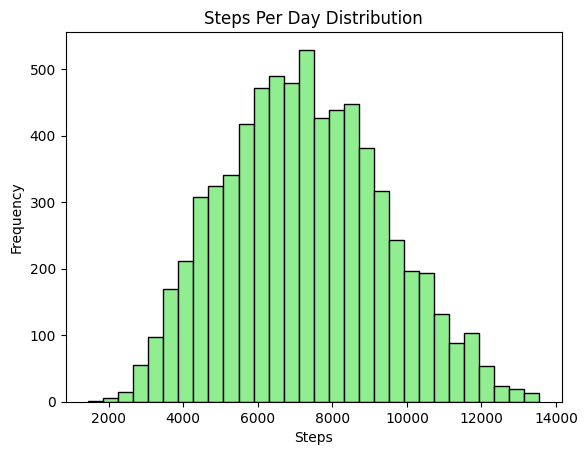

In [ ]:
plt.figure()
plt.hist(df['steps_per_day'], bins=30, color='lightgreen', edgecolor='black')
plt.title("Steps Per Day Distribution")
plt.xlabel("Steps")
plt.ylabel("Frequency")
plt.show()

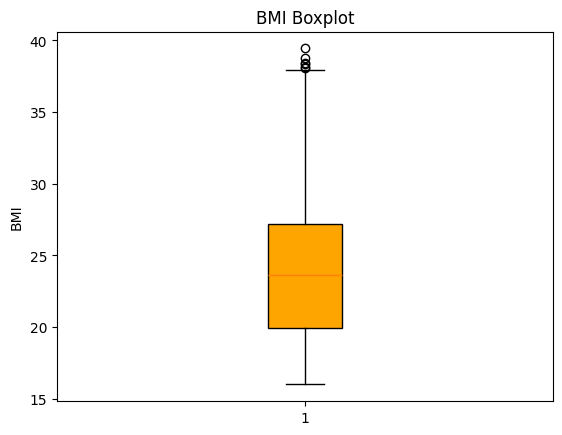

In [ ]:
plt.figure()
plt.boxplot(df['bmi'], patch_artist=True,
            boxprops=dict(facecolor='orange'))
plt.title("BMI Boxplot")
plt.ylabel("BMI")
plt.show()

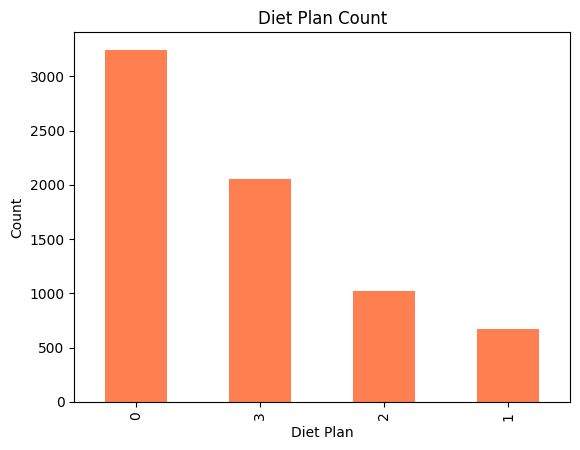

In [ ]:
plt.figure()
df['nutrition_plan'].value_counts().plot(kind='bar', color='coral')
plt.title("Diet Plan Count")
plt.xlabel("Diet Plan")
plt.ylabel("Count")
plt.show()

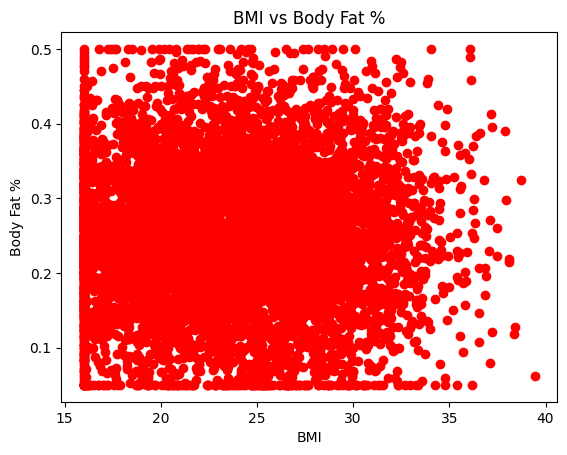

In [ ]:
plt.figure()
plt.scatter(df['bmi'], df['body_fat_percentage'], color='red')
plt.title("BMI vs Body Fat %")
plt.xlabel("BMI")
plt.ylabel("Body Fat %")
plt.show()

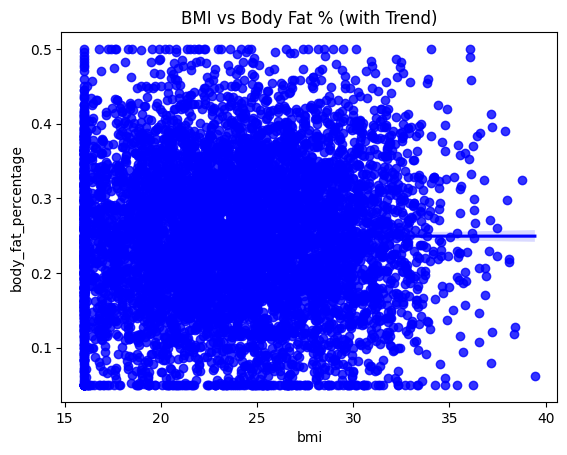

In [ ]:
import seaborn as sns

plt.figure()
sns.regplot(x='bmi', y='body_fat_percentage', data=df, color='blue')
plt.title("BMI vs Body Fat % (with Trend)")
plt.show()

/tmp/ipykernel_14231/2593196532.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='nutrition_plan', y='bmi', data=df, palette='Set2')


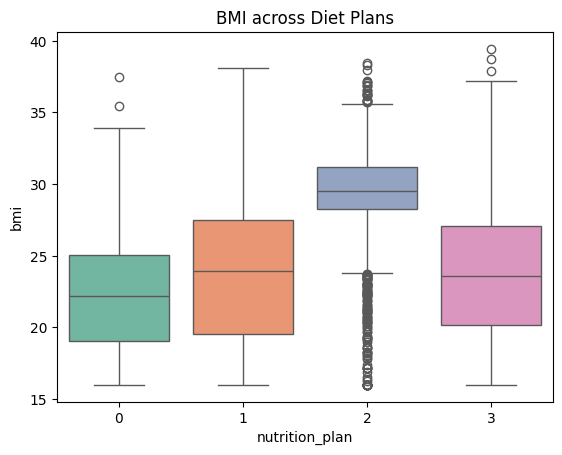

In [ ]:
plt.figure()
sns.boxplot(x='nutrition_plan', y='bmi', data=df, palette='Set2')
plt.title("BMI across Diet Plans")
plt.show()

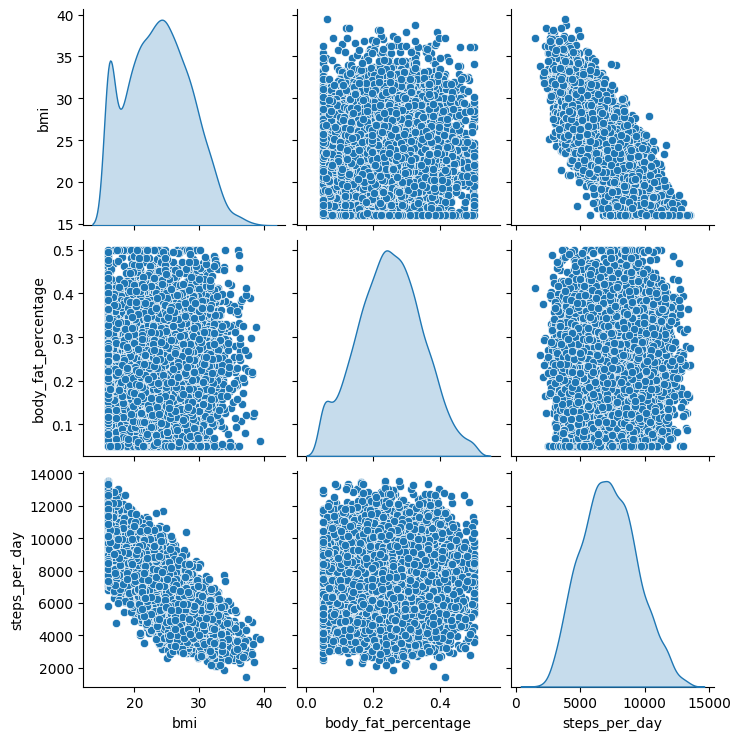

In [ ]:
sns.pairplot(df[['bmi', 'body_fat_percentage', 'steps_per_day']],
             diag_kind='kde')
plt.show()

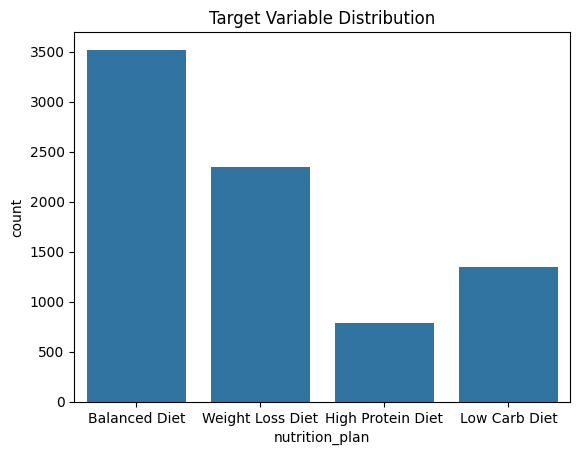

In [ ]:
sns.countplot(x='nutrition_plan', data=df)
plt.title("Target Variable Distribution")
plt.show()

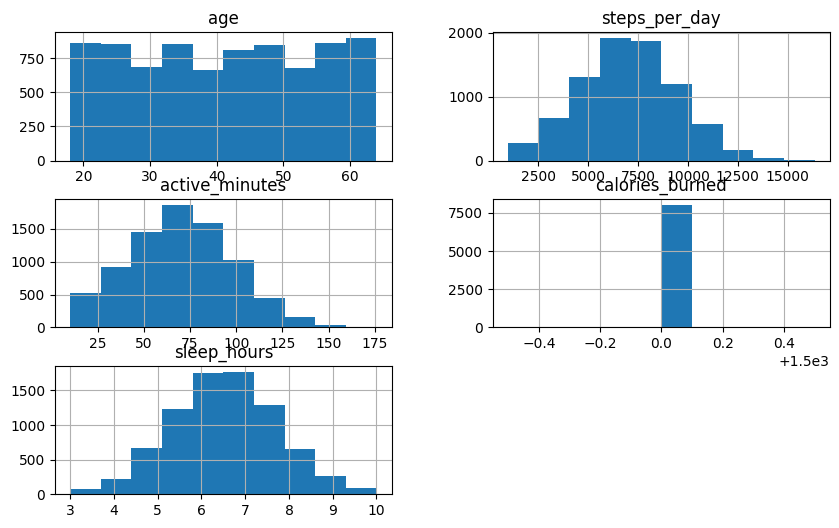

In [ ]:
df.select_dtypes(include=np.number).iloc[:, :5].hist(figsize=(10,6))
plt.show()

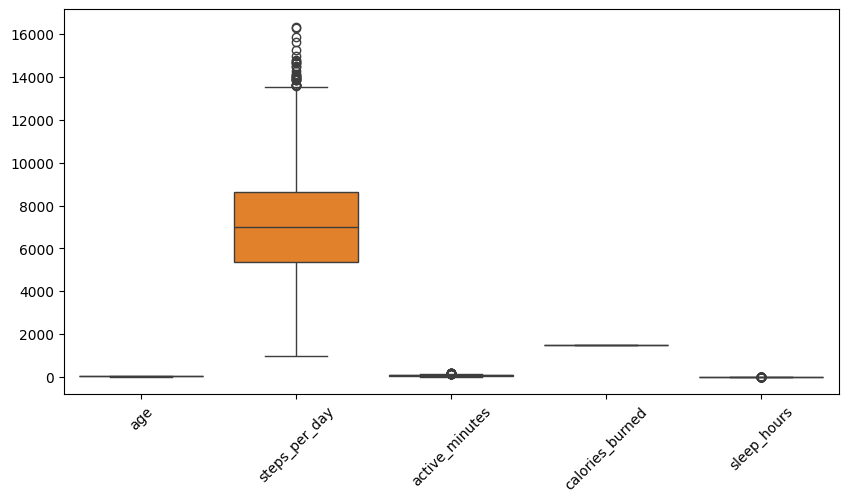

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number).iloc[:, :5])
plt.xticks(rotation=45)
plt.show()

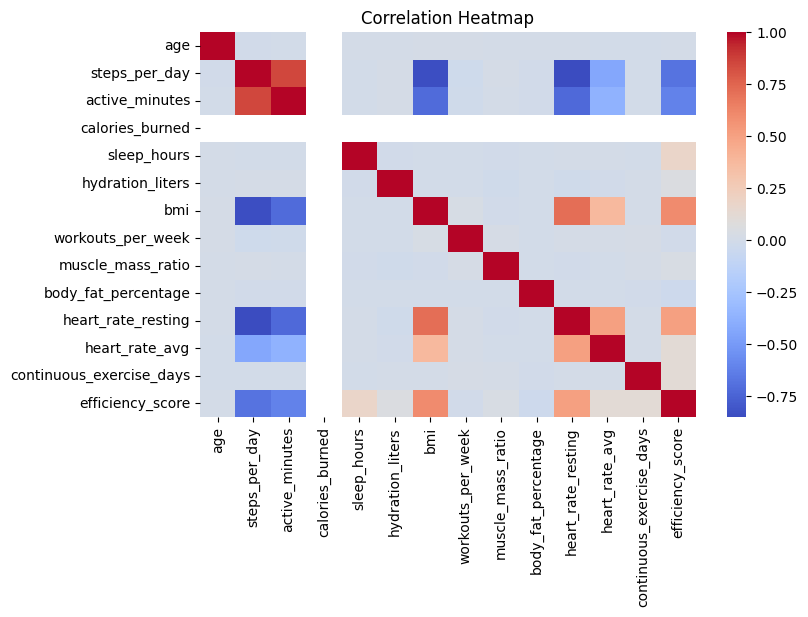

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

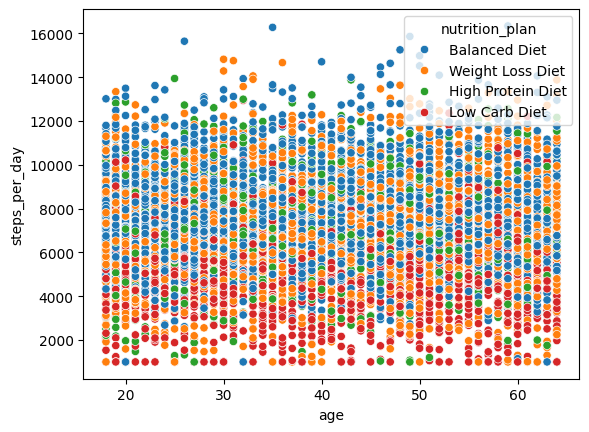

In [ ]:
cols = df.select_dtypes(include=np.number).columns
sns.scatterplot(x=cols[0], y=cols[1], hue='nutrition_plan', data=df)
plt.show()

**Outlier Detection and removal**

In [ ]:
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = ((df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)
print("Outliers detected:", outlier_condition.sum())

# Remove outliers and compare shapes
initial_shape = df.shape
df = df.loc[~outlier_condition].reset_index(drop=True)
print("Shape before outlier removal:", initial_shape)
print("Shape after outlier removal:", df.shape)

Outliers detected: 1011
Shape before outlier removal: (8000, 16)
Shape after outlier removal: (6989, 16)


**Assigning features to X and Y **

In [ ]:
key_features = ['bmi', 'active_minutes', 'body_fat_percentage']
X = df[key_features]

y = df['nutrition_plan']

print("Feature columns:", X.columns.tolist())
print("Target classes:", y.unique())

Feature columns: ['bmi', 'active_minutes', 'body_fat_percentage']
Target classes: ['Balanced Diet' 'Weight Loss Diet' 'High Protein Diet' 'Low Carb Diet']


**Applying Standardization ansd Normalization**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

norm = MinMaxScaler()
X_train_norm = norm.fit_transform(X_train)
X_test_norm = norm.transform(X_test)

print("Standardized sample:\n", X_train_std[:3])
print("Normalized sample:\n", X_train_norm[:3])

Standardized sample:
 [[ 0.88532451  0.85198537 -0.31049724]
 [-0.30906427  1.04909746  0.18751569]
 [-1.58832298  0.30007152 -0.42462521]]
Normalized sample:
 [[0.50981229 0.61764706 0.37777778]
 [0.26365188 0.65441176 0.48444444]
 [0.         0.51470588 0.35333333]]


**Label encoding**

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop(columns=['nutrition_plan'])   # change if needed
y = df['nutrition_plan']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

**Decision tree Classifier model**

> Add blockquote



In [ ]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

**RandomForest Classifier model**

In [ ]:
rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**KNN classifier model**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

**Testing the models**

In [ ]:
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_knn))

Decision Tree: 0.8819742489270386
Random Forest: 0.8834048640915594
KNN: 0.6738197424892703


In [ ]:

models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN': knn
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {results[name]:.4f}")

best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"\nBest model: {best_name} with accuracy {results[best_name]:.4f}")

Decision Tree Accuracy: 0.8820
Random Forest Accuracy: 0.8834
KNN Accuracy: 0.6738

Best model: Random Forest with accuracy 0.8834


**Taking the best model**

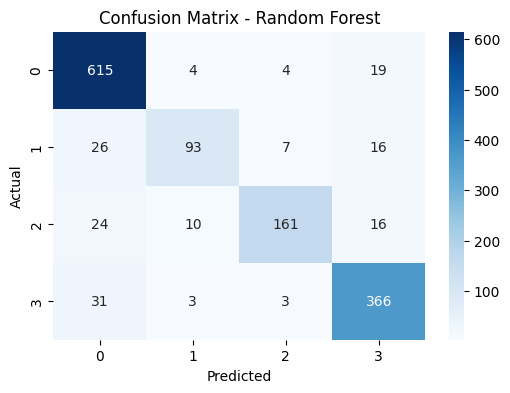

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       642
           1       0.85      0.65      0.74       142
           2       0.92      0.76      0.83       211
           3       0.88      0.91      0.89       403

    accuracy                           0.88      1398
   macro avg       0.88      0.82      0.85      1398
weighted avg       0.88      0.88      0.88      1398



In [ ]:
best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

print(classification_report(y_test, best_pred))

**Explaining the predictions**

In [ ]:
def explain_diet(plan):
    if plan == "Weight Loss Diet":
        return "Focus on a calorie deficit: reduce portion sizes, eat more vegetables and whole grains, avoid sugary drinks and processed foods. Aim for 500-calorie daily deficit for safe weight loss."
    elif plan == "High Protein Diet":
        return "Increase protein intake: include lean meats like chicken and turkey, eggs, fish, dairy products like paneer and yogurt, legumes such as dal and lentils. Protein helps build muscle and keeps you full."
    elif plan == "Low Carb Diet":
        return "Reduce carbohydrates: limit breads, pasta, rice, and sugars. Focus on vegetables, healthy fats (avocados, nuts, olive oil), and lean proteins. This can help with weight management and blood sugar control."
    else:
        return "Maintain a balanced diet: include a mix of carbs (whole grains), proteins (meat, eggs, dairy), healthy fats (nuts, oils), and plenty of fruits and vegetables for overall health and energy."



> **User input prediction**



In [ ]:
import pandas as pd
import numpy as np


print("🔹 Enter Your Details 🔹")

def get_input(prompt):
    while True:
        try:
            return float(input(prompt))
        except ValueError:
            print("Enter a valid number!")

bmi = get_input("Enter BMI: ")
active = get_input("Enter Active Minutes: ")
fat = get_input("Enter Body Fat Percentage: ")

user_input_features = {
    'bmi': bmi,
    'active_minutes': active,
    'body_fat_percentage': fat
}


final_input_dict = {}

for col in X.columns:
    final_input_dict[col] = np.random.uniform(df[col].min(), df[col].max())

for key in user_input_features:
    final_input_dict[key] = user_input_features[key]

user_data = pd.DataFrame([final_input_dict], columns=X.columns)


user_data_scaled = scaler.transform(user_data)


probs = best_model.predict_proba(user_data_scaled)[0]

classes = le.inverse_transform(best_model.classes_)


print("\n🔍 Prediction Probabilities:")
for c, p in zip(classes, probs):
    print(f"{c}: {round(p*100,2)}%")

predicted_nutrition_plan = np.random.choice(classes, p=probs)

print("\n✅ Recommended Nutrition Plan:", predicted_nutrition_plan)


def explain_diet(plan):
    if plan == "Weight Loss Diet":
        return "Reduce calories, avoid sugar, increase fiber."
    elif plan == "High Protein Diet":
        return "Eat protein-rich foods like eggs, dal, chicken."
    elif plan == "Low Carb Diet":
        return "Reduce carbs like rice and bread."
    else:
        return "Maintain a balanced diet."

print("💡 Suggestion:", explain_diet(predicted_nutrition_plan))

🔹 Enter Your Details 🔹
Enter BMI: 789
Enter Active Minutes: 58
Enter Body Fat Percentage: 346

🔍 Prediction Probabilities:
Balanced Diet: 8.0%
High Protein Diet: 20.0%
Low Carb Diet: 18.0%
Weight Loss Diet: 54.0%

✅ Recommended Nutrition Plan: Weight Loss Diet
💡 Suggestion: Reduce calories, avoid sugar, increase fiber.
